<a href="https://colab.research.google.com/github/SRET-College/Sem-6-NN-and-DL/blob/main/NN_and_DL_Expt_3A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. DATA ACQUISITION
print("Loading data...")
# Load the MNIST dataset (60,000 training images, 10,000 test images)
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Save original test images for display
X_test_images = X_test

Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 2. PREPROCESSING & NORMALIZATION
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

In [4]:
# 3. LABEL ENCODING (One-Hot Encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [5]:
# 4. MODEL ARCHITECTURE & TRAINING
with tf.device('/GPU:0'):
    model = Sequential([
        Dense (128, activation='relu', input_shape=(784,)),
        Dense (64, activation='relu'),
        Dense (10, activation='softmax')
    ])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nStarting training...")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting training...


In [6]:
history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9235 - loss: 0.2591 - val_accuracy: 0.9682 - val_loss: 0.1088
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9679 - loss: 0.1060 - val_accuracy: 0.9700 - val_loss: 0.0955
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9766 - loss: 0.0741 - val_accuracy: 0.9728 - val_loss: 0.0856
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9821 - loss: 0.0558 - val_accuracy: 0.9753 - val_loss: 0.0811
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9857 - loss: 0.0433 - val_accuracy: 0.9768 - val_loss: 0.0824
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9889 - loss: 0.0341 - val_accuracy: 0.9803 - val_loss: 0.0742
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9904 - loss: 0.0278 - val_accuracy: 0.9792 - val_loss: 0.0801
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9917 - loss: 0.0244 - 

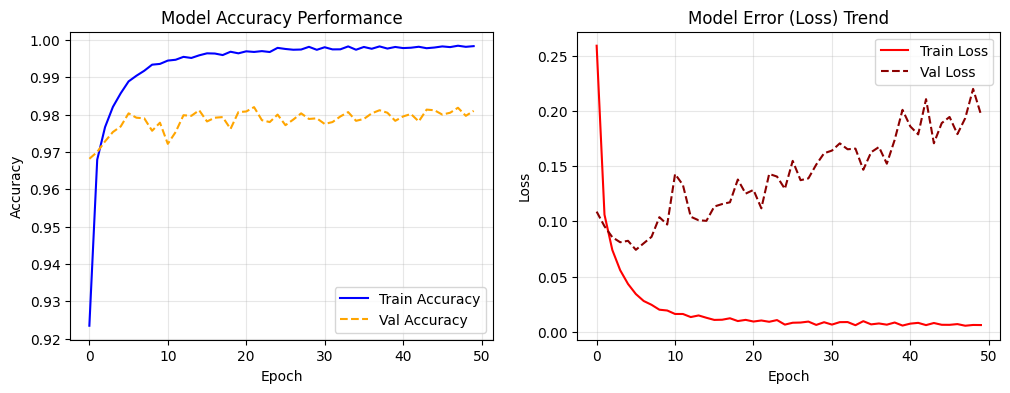

In [7]:
# 5. PLOTTING TRAINING HISTORY
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
# Training accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
plt.title('Model Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
# Training loss
plt.plot(history.history['loss'], label='Train Loss', color='red')

# Validation loss
plt.plot(history.history['val_loss'], label='Val Loss', color='darkred', linestyle='--')
plt.title('Model Error (Loss) Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Generating predictions on unseen test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


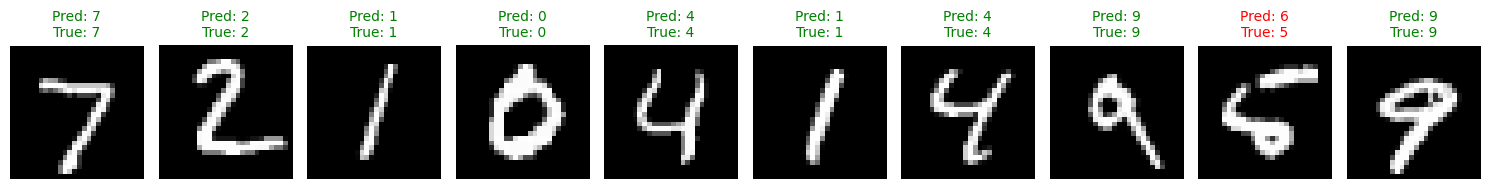

In [8]:
# 6. PREDICTIONS & VISUALIZATION
print("\nGenerating predictions on unseen test data...")
predictions = model.predict(X_test)
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_test_images [i], cmap='gray')
    pred_label = np.argmax(predictions [i])
    true_label = y_test[i]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# 7. FINAL EVALUATION
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n[FINAL REPORT] Test Loss: {loss:.4f}")
print(f"[FINAL REPORT] Test Accuracy: {accuracy*100:.2f}%")


[FINAL REPORT] Test Loss: 0.1837
[FINAL REPORT] Test Accuracy: 97.77%
